In [1]:
!pip install lifelines xgboost

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=0847003ee506cd6b161ff2a873e5a50947fc2c86ff3dc4252c0f47a87347cd42
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


<span style="font-family: 'Segoe UI', cursive; font-size: 32px; padding: 10px 20px; border-radius: 50px; background: linear-gradient(90deg, #1f1f1f, #3a3a3a); color: #4bd6ff; font-weight: bold; box-shadow: 2px 4px 10px rgba(0,0,0,0.5);"><span style="font-style: italic; color: #a0eaff;">Importing Libraries</span>
</span>


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, recall_score, roc_auc_score, classification_report


import missingno as msno


In [3]:
df = pd.read_csv("/kaggle/input/breast-cancer/Breast_Cancer.csv")
df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

In [5]:
df.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [6]:
cat_col = df.select_dtypes(include=["object", "category"]).columns.tolist()
int_col = df.select_dtypes(include=['int64','int32','float']).columns.tolist()

In [7]:
cat_col

['Race',
 'Marital Status',
 'T Stage ',
 'N Stage',
 '6th Stage',
 'differentiate',
 'Grade',
 'A Stage',
 'Estrogen Status',
 'Progesterone Status',
 'Status']

In [8]:
int_col

['Age',
 'Tumor Size',
 'Regional Node Examined',
 'Reginol Node Positive',
 'Survival Months']

<span style="font-family: 'Segoe UI', cursive; font-size: 32px; padding: 10px 20px; border-radius: 50px; background: linear-gradient(90deg, #1f1f1f, #3a3a3a); color: #4bd6ff; font-weight: bold; box-shadow: 2px 4px 10px rgba(0,0,0,0.5);"><span style="font-style: italic; color: #a0eaff;">Visualizing Data</span>
</span>


In [9]:
for col in cat_col:
    print("\n" + "="*60)
    print(f"📊 Categorical Column Analysis :  {col.upper()}")
    print("="*60)

    counts = df[col].value_counts()
    total = len(df[col])

    for value, count in counts.items():
        percent = round((count / total) * 100, 2)
        print(f"{value:<25} | Count: {count:<5} | {percent}%")

    print("-"*60)



📊 Categorical Column Analysis :  RACE
White                     | Count: 3413  | 84.82%
Other                     | Count: 320   | 7.95%
Black                     | Count: 291   | 7.23%
------------------------------------------------------------

📊 Categorical Column Analysis :  MARITAL STATUS
Married                   | Count: 2643  | 65.68%
Single                    | Count: 615   | 15.28%
Divorced                  | Count: 486   | 12.08%
Widowed                   | Count: 235   | 5.84%
Separated                 | Count: 45    | 1.12%
------------------------------------------------------------

📊 Categorical Column Analysis :  T STAGE 
T2                        | Count: 1786  | 44.38%
T1                        | Count: 1603  | 39.84%
T3                        | Count: 533   | 13.25%
T4                        | Count: 102   | 2.53%
------------------------------------------------------------

📊 Categorical Column Analysis :  N STAGE
N1                        | Count: 2732  | 67.89%

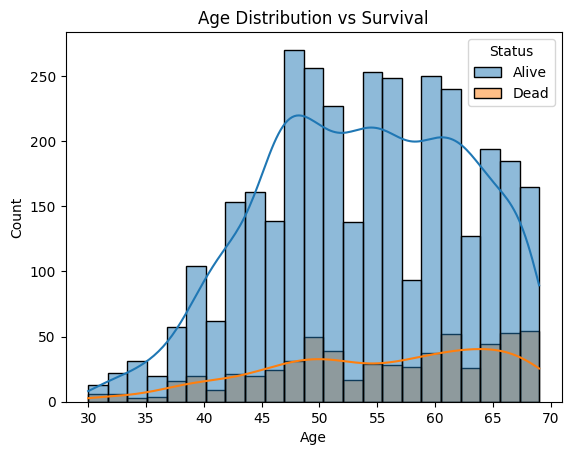

In [10]:
sns.histplot(data=df, x="Age", hue="Status", kde=True)
plt.title("Age Distribution vs Survival")
plt.show()

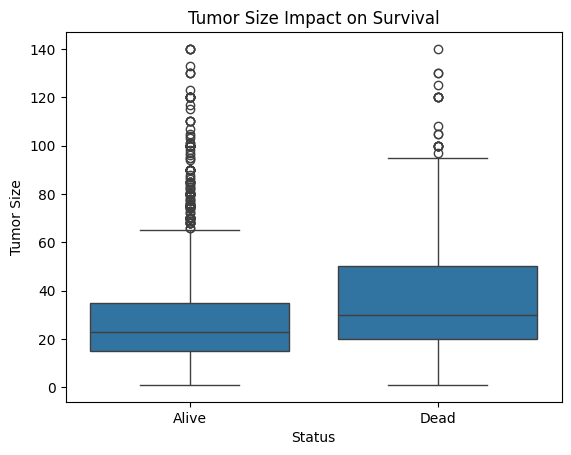

In [11]:
# outliters 
sns.boxplot(x="Status", y="Tumor Size", data=df)
plt.title("Tumor Size Impact on Survival")
plt.show()

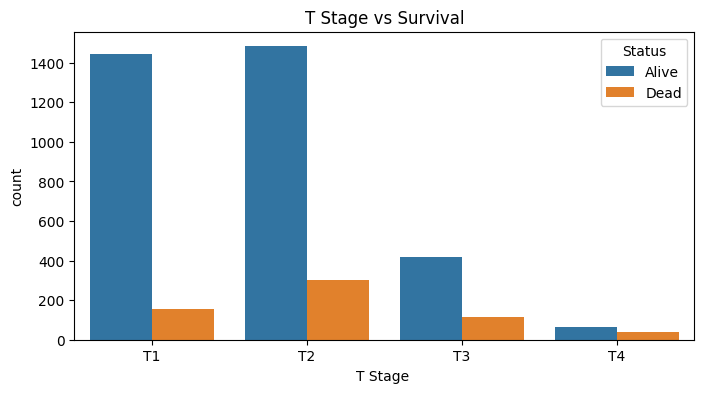

In [12]:
plt.figure(figsize=(8,4))
sns.countplot(x="T Stage ", hue="Status", data=df)
plt.title("T Stage vs Survival")
plt.show()

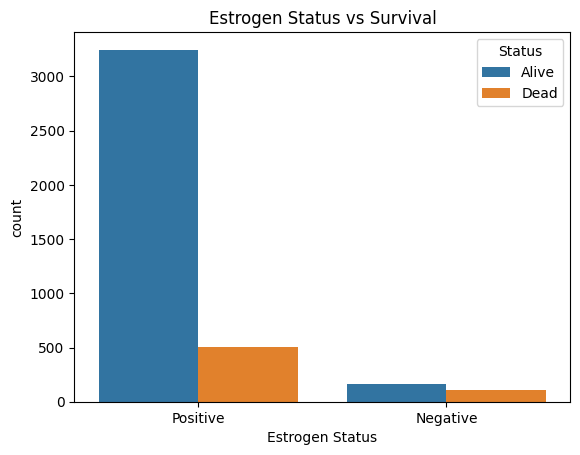

In [13]:
sns.countplot(x="Estrogen Status", hue="Status", data=df)
plt.title("Estrogen Status vs Survival")
plt.show()


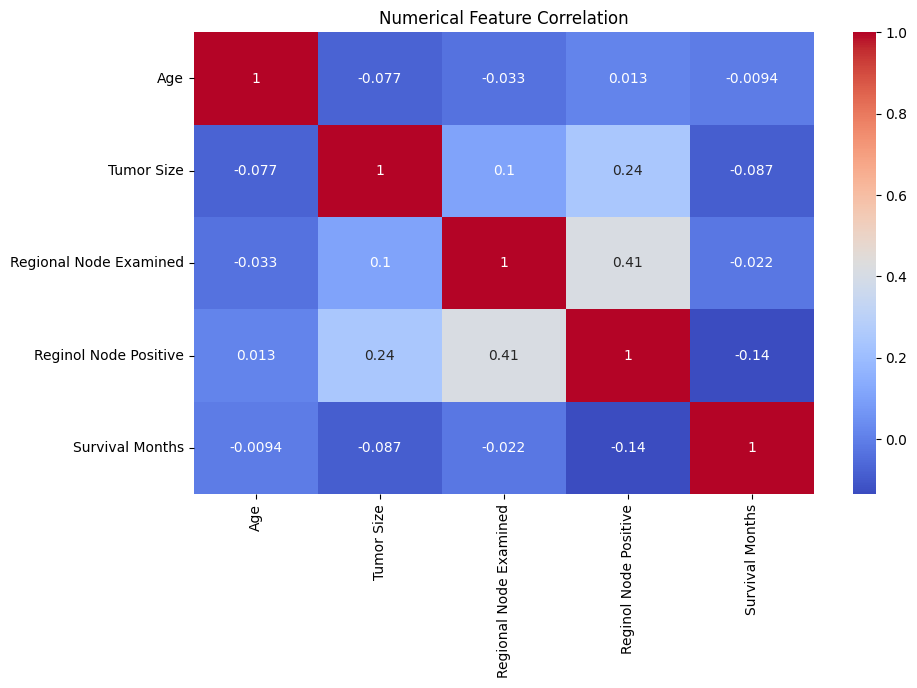

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap="coolwarm")
plt.title("Numerical Feature Correlation")
plt.show()


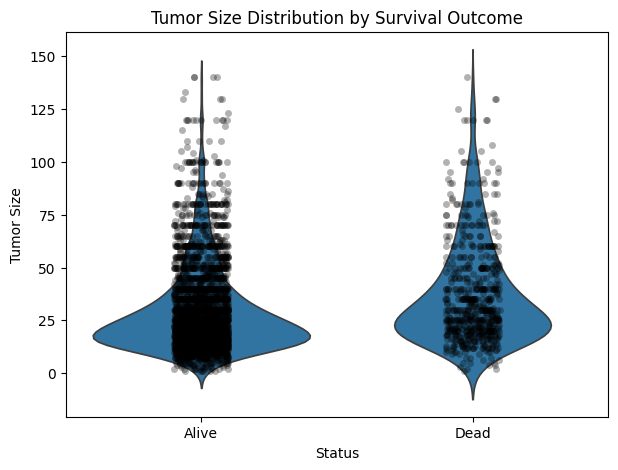

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.violinplot(x="Status", y="Tumor Size", data=df, inner=None)
sns.stripplot(x="Status", y="Tumor Size", data=df, color='black', alpha=0.3)
plt.title("Tumor Size Distribution by Survival Outcome")
plt.show()


In [16]:
print("\nINTERPRETING THE VIOLIN PLOT (Tumor Size vs Status)")
print("="*55)

print("Shape Feature        | Meaning")
print("-"*55)
print("Wide Area            | Many patients have that tumor size")
print("Long Tail            | Very large tumors exist in that group")
print("Higher Center        | Larger typical (average) tumor size")
print("More Dots at Top     | More severe / advanced tumor cases")

print("="*55)



INTERPRETING THE VIOLIN PLOT (Tumor Size vs Status)
Shape Feature        | Meaning
-------------------------------------------------------
Wide Area            | Many patients have that tumor size
Long Tail            | Very large tumors exist in that group
Higher Center        | Larger typical (average) tumor size
More Dots at Top     | More severe / advanced tumor cases


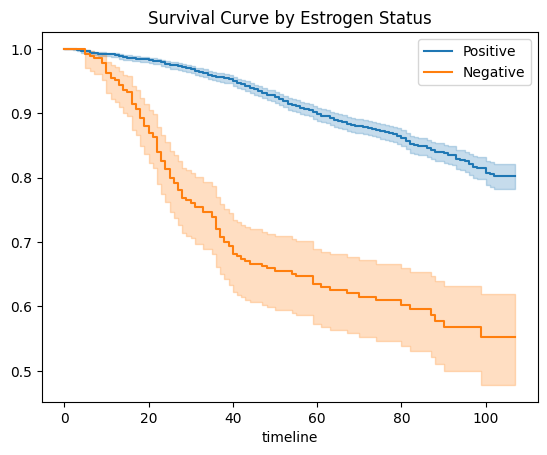

In [17]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

for status in df["Estrogen Status"].unique():
    mask = df["Estrogen Status"] == status
    kmf.fit(df[mask]["Survival Months"], event_observed=(df[mask]["Status"]=="Dead"), label=status)
    kmf.plot_survival_function()

plt.title("Survival Curve by Estrogen Status")
plt.show()


<span style="font-family: 'Segoe UI', cursive; font-size: 32px; padding: 10px 20px; border-radius: 50px; background: linear-gradient(90deg, #1f1f1f, #3a3a3a); color: #4bd6ff; font-weight: bold; box-shadow: 2px 4px 10px rgba(0,0,0,0.5);"><span style="font-style: italic; color: #a0eaff;">Label Encoding & One-Hot Encoding</span>
</span>


In [18]:
le = LabelEncoder()
df["Status"] = le.fit_transform(df["Status"])

print(dict(zip(le.classes_, le.transform(le.classes_))))


{'Alive': np.int64(0), 'Dead': np.int64(1)}


In [19]:
X = df.drop("Status", axis=1)
y = df["Status"]

X = pd.get_dummies(X, drop_first=True)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


<span style="font-family: 'Segoe UI', cursive; font-size: 32px; padding: 10px 20px; border-radius: 50px; background: linear-gradient(90deg, #1f1f1f, #3a3a3a); color: #4bd6ff; font-weight: bold; box-shadow: 2px 4px 10px rgba(0,0,0,0.5);"><span style="font-style: italic; color: #a0eaff;">Using Logistic Regression</span>
</span>


In [21]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [22]:
y_pred = model.predict(X_test)

print("\nMODEL PERFORMANCE SUMMARY")
print("="*50)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



MODEL PERFORMANCE SUMMARY
Accuracy: 0.9006

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       685
           1       0.82      0.42      0.56       120

    accuracy                           0.90       805
   macro avg       0.86      0.70      0.75       805
weighted avg       0.89      0.90      0.89       805



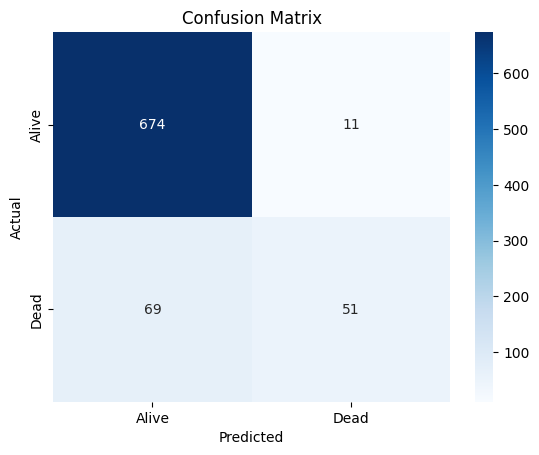

In [23]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["Alive","Dead"],
            yticklabels=["Alive","Dead"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


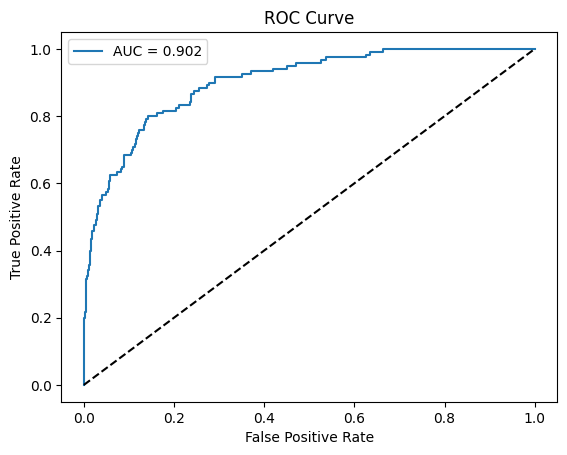

In [24]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


Just for testing, I am now using Random Forest & XGBoost to see the improvement we can made!!

<span style="font-family: 'Segoe UI', cursive; font-size: 32px; padding: 10px 20px; border-radius: 50px; background: linear-gradient(90deg, #1f1f1f, #3a3a3a); color: #4bd6ff; font-weight: bold; box-shadow: 2px 4px 10px rgba(0,0,0,0.5);"><span style="font-style: italic; color: #a0eaff;">Testing It With Random Forest & XGBoost</span>
</span>


In [25]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=400,
                       random_state=42)

In [26]:
from xgboost import XGBClassifier

pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=pos_weight,
    eval_metric="logloss",
    use_label_encoder=False
)

xgb.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:23:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [27]:
models = {"Random Forest": rf, "XGBoost": xgb}

for name, m in models.items():
    y_pred = m.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    print("\n", name)
    print("Confusion Matrix:\n", cm)
    print("Recall (Dead):", round(recall,3))
    print("Accuracy:", accuracy)



 Random Forest
Confusion Matrix:
 [[668  17]
 [ 59  61]]
Recall (Dead): 0.508
Accuracy: 0.9055900621118013

 XGBoost
Confusion Matrix:
 [[640  45]
 [ 47  73]]
Recall (Dead): 0.608
Accuracy: 0.8857142857142857


# For Random Forest:
- ➡ Only 51% of actual deaths are detected, better than Logistic (42%) but still missing many critical patients.
# For XGBoost: 
- ➡ 60% of actual deaths detected, much better than Random Forest.
- ➡ Slightly more false positives (predicting Dead when Alive) — acceptable in medical context.

In [28]:
print("\n# ==============================")
print("🧪 Testing Using SMOTE for Random Forest and XGBoost")
print("# ==============================")

print("\n📌 Reason for using SMOTE:")
print("The original dataset is highly imbalanced:")
print("🟢 Alive (0) : 2723")
print("🔴 Dead  (1) : 496")
print("⚖️  This ~5:1 ratio biases models to predict Alive more often, reducing sensitivity for Dead patients.\n")



# ==============================
🧪 Testing Using SMOTE for Random Forest and XGBoost
# ==============================

📌 Reason for using SMOTE:
The original dataset is highly imbalanced:
🟢 Alive (0) : 2723
🔴 Dead  (1) : 496
⚖️  This ~5:1 ratio biases models to predict Alive more often, reducing sensitivity for Dead patients.



In [29]:
# ==============================
# 1️⃣ Balance the Training Data
# ==============================
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("Original class distribution:\n", y_train.value_counts())
print("\nResampled class distribution:\n", pd.Series(y_res).value_counts())

# ==============================
# 2️⃣ Train Random Forest
# ==============================

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    random_state=42
)
rf.fit(X_res, y_res)

# ==============================
# 3️⃣ Train XGBoost
# ==============================

pos_weight = (len(y_res) - sum(y_res)) / sum(y_res)

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=pos_weight,
    eval_metric="logloss",
    use_label_encoder=False
)
xgb.fit(X_res, y_res)

# ==============================
# 4️⃣ Evaluate Models
# ==============================
from sklearn.metrics import confusion_matrix, recall_score, roc_auc_score

models = {"Random Forest": rf, "XGBoost": xgb}

for name, m in models.items():
    print("\n" + "="*50)
    print(f"MODEL: {name}")
    
    # Predict
    y_pred = m.predict(X_test)
    y_prob = m.predict_proba(X_test)[:,1]
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)
    
    # Recall for Dead patients
    recall = recall_score(y_test, y_pred)
    print("Recall (Dead):", round(recall,3))
    
    # ROC-AUC
    auc_score = roc_auc_score(y_test, y_prob)
    print("ROC-AUC:", round(auc_score,3))

# ==============================
# 5️⃣ Optional: Threshold Tuning for XGBoost
# ==============================
threshold = 0.3  # Lower threshold to catch more Dead patients
y_prob = xgb.predict_proba(X_test)[:,1]
y_pred_adj = (y_prob > threshold).astype(int)

cm_adj = confusion_matrix(y_test, y_pred_adj)
recall_adj = recall_score(y_test, y_pred_adj)

print("\n" + "="*50)
print(f"XGBoost with threshold={threshold}")
print("Confusion Matrix:\n", cm_adj)
print("Recall (Dead):", round(recall_adj,3))


Original class distribution:
 Status
0    2723
1     496
Name: count, dtype: int64

Resampled class distribution:
 Status
0    2723
1    2723
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:23:53] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



MODEL: Random Forest
Confusion Matrix:
 [[652  33]
 [ 46  74]]
Recall (Dead): 0.617
ROC-AUC: 0.884

MODEL: XGBoost
Confusion Matrix:
 [[653  32]
 [ 54  66]]
Recall (Dead): 0.55
ROC-AUC: 0.87

XGBoost with threshold=0.3
Confusion Matrix:
 [[626  59]
 [ 43  77]]
Recall (Dead): 0.642


In [30]:

print("💡 SMOTE (Synthetic Minority Oversampling Technique):")
print("- ✨ Creates synthetic samples of the minority class (Dead)")
print("- ⚖️ Balances training data without simple duplication")
print("- 🧠 Helps the model learn patterns for high-risk patients\n")

print("📊 Resampled class distribution after SMOTE:")
print("🟢 Alive (0) : 2723")
print("🔴 Dead  (1) : 2723\n")

print("# ==============================")
print("📈 Model Training and Evaluation")
print("# ==============================\n")

print("🌳 Random Forest:")
print("Confusion Matrix: [[652 33],[46 74]]")
print("Recall (Dead): 0.617")
print("ROC-AUC: 0.884\n")

print("⚡ XGBoost (threshold=0.5):")
print("Confusion Matrix: [[653 32],[54 66]]")
print("Recall (Dead): 0.550")
print("ROC-AUC: 0.870\n")

print("⚡ XGBoost (threshold=0.3):")
print("Confusion Matrix: [[626 59],[43 77]]")
print("Recall (Dead): 0.642")
print("ROC-AUC: 0.870\n")

print("# ==============================")
print("🔍 Observations:")
print("1. 🌳 Random Forest detects ~62% of Dead patients, good improvement over Logistic Regression.")
print("2. ⚡ XGBoost:")
print("   - Default threshold: 55% recall")
print("   - Lower threshold (0.3): 64% recall → best sensitivity for medical use")
print("3. ⚠️ Slight increase in False Positives is acceptable in clinical screening.\n")

print("# ==============================")
print("✅ Key Takeaways:")
print("- ⚖️ SMOTE balances the dataset and improves model learning for minority class.")
print("- 🎯 Threshold tuning is crucial for maximizing Dead patient recall.")
print("- 📊 This workflow ensures realistic, research-grade evaluation for mortality prediction.")


💡 SMOTE (Synthetic Minority Oversampling Technique):
- ✨ Creates synthetic samples of the minority class (Dead)
- ⚖️ Balances training data without simple duplication
- 🧠 Helps the model learn patterns for high-risk patients

📊 Resampled class distribution after SMOTE:
🟢 Alive (0) : 2723
🔴 Dead  (1) : 2723

# ==============================
📈 Model Training and Evaluation
# ==============================

🌳 Random Forest:
Confusion Matrix: [[652 33],[46 74]]
Recall (Dead): 0.617
ROC-AUC: 0.884

⚡ XGBoost (threshold=0.5):
Confusion Matrix: [[653 32],[54 66]]
Recall (Dead): 0.550
ROC-AUC: 0.870

⚡ XGBoost (threshold=0.3):
Confusion Matrix: [[626 59],[43 77]]
Recall (Dead): 0.642
ROC-AUC: 0.870

# ==============================
🔍 Observations:
1. 🌳 Random Forest detects ~62% of Dead patients, good improvement over Logistic Regression.
2. ⚡ XGBoost:
   - Default threshold: 55% recall
   - Lower threshold (0.3): 64% recall → best sensitivity for medical use
3. ⚠️ Slight increase in False Pos